# Predicting Heart Disease Risk with Logistic Regression

### Identifying Key Behavioral and Health Risk Factors Using the CDC BRFSS 2015 Dataset

**Author:** Nancy Le

---

## Introduction

Cardiovascular disease remains one of the leading causes of death in the United States, and much of the variation in risk is driven by behavioral and health factors that are observable well before a diagnosis: smoking, physical activity, diet, blood pressure, and general health status, among others.

This project uses the CDC's 2015 Behavioral Risk Factor Surveillance System (BRFSS) dataset, a survey of **253,680 respondents**, to investigate which factors are most strongly associated with heart disease or heart attack, and how well a relatively simple model can predict this outcome.

**Central Question:** Which behavioral and health indicators are most predictive of heart disease, and how well can a logistic regression model, built using a principled feature selection process, distinguish between individuals who have and have not experienced heart disease or a heart attack?

This is framed as a binary classification problem, where the response variable `HeartDiseaseorAttack` indicates whether a respondent has ever been told they had coronary heart disease (CHD) or a myocardial infarction (MI).

## Setup

Importing libraries used for data exploration, modeling, feature selection, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Data Exploration

The dataset contains 21 binary, ordinal, or continuous features describing each respondent's health behaviors (e.g. smoking, heavy alcohol consumption, physical activity), health conditions (e.g. high blood pressure, diabetes, BMI), and demographics (age, sex, income, education). The response variable, `HeartDiseaseorAttack`, is binary (1 = has had heart disease or a heart attack, 0 = has not).

In [2]:
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')
df.head(20)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,2.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


### A Closer Look at Heavy Alcohol Consumption

One of the more counterintuitive patterns in this dataset involves `HvyAlcoholConsump`. A naive expectation might be that heavy drinkers would show a *higher* rate of heart disease. Examining the data tells a different story.

In [3]:
print(df.groupby('HvyAlcoholConsump')['HeartDiseaseorAttack'].value_counts(normalize=True).unstack())

HeartDiseaseorAttack       0.0       1.0
HvyAlcoholConsump                       
0.0                   0.903748  0.096252
1.0                   0.940516  0.059484


In [4]:
print(df.groupby('HvyAlcoholConsump')[['Age', 'Sex']].mean())

                        Age       Sex
HvyAlcoholConsump                    
0.0                8.057889  0.439647
1.0                7.599327  0.452020


In [5]:
print(df.corr()['HvyAlcoholConsump'].sort_values())

Diabetes               -0.057882
BMI                    -0.048736
DiffWalk               -0.037668
GenHlth                -0.036724
Fruits                 -0.035288
Age                    -0.034578
HeartDiseaseorAttack   -0.028991
PhysHlth               -0.026415
CholCheck              -0.023730
Stroke                 -0.016950
HighChol               -0.011543
AnyHealthcare          -0.010488
HighBP                 -0.003972
NoDocbcCost             0.004684
Sex                     0.005740
PhysActivity            0.012392
Veggies                 0.021064
Education               0.023997
MentHlth                0.024716
Income                  0.053619
Smoker                  0.101619
HvyAlcoholConsump       1.000000
Name: HvyAlcoholConsump, dtype: float64


**Observation:** Heavy alcohol consumers show a *lower* rate of heart disease in this sample. Rather than reflecting a protective effect of alcohol, this is best explained by **survivorship bias** combined with demographic confounding: heavy drinkers in this survey tend to be younger on average, and individuals who develop serious heart conditions earlier in life may reduce or stop drinking, or may not survive to be sampled at all. This is a useful reminder that raw correlations in observational health data can be misleading without accounting for the population's age structure and survivorship effects.

## Train/Test Split

Before any modeling, the data is split into training (70%) and test (30%) sets. All feature selection and hyperparameter decisions are made using the training set (with cross-validation), and the test set is reserved for final evaluation only.

In [6]:
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Baseline Model: Full-Feature Logistic Regression Pipeline

As an initial baseline, I built a simple `sklearn` `Pipeline` that standardizes all features and fits an unpenalized logistic regression using **every** available predictor. This establishes a performance ceiling-ish reference point before any feature selection.

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty=None, max_iter=1000))
])
pipeline.fit(X_train, y_train)

/Users/nancyle/miniforge3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with 

In [8]:
pipeline_test_acc = pipeline.score(X_test, y_test)
pipeline_probs = pipeline.predict_proba(X_test)[:, 1]
pipeline_roc_auc = roc_auc_score(y_test, pipeline_probs)

print(f"Pipeline Test Accuracy: {pipeline_test_acc:.4f}")
print(f"Pipeline Test ROC AUC: {pipeline_roc_auc:.4f}")

Pipeline Test Accuracy: 0.9086
Pipeline Test ROC AUC: 0.8456


## Base Model (Unscaled, All Features)

For comparison, I also fit a standard (penalized, default) logistic regression on the raw, unscaled features. This serves as a second reference point and confirms that the choice of scaling and regularization has only a modest effect on overall discriminative performance for this dataset.

In [9]:
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train, y_train)

base_model_train_acc = base_model.score(X_train, y_train)
base_model_test_acc = base_model.score(X_test, y_test)

y_probs = base_model.predict_proba(X_test)[:, 1]
base_model_roc_auc = roc_auc_score(y_test, y_probs)

In [10]:
print(f'Base Model Training Accuracy: {base_model_train_acc:.4f}')
print(f'Base Model Test Accuracy: {base_model_test_acc:.4f}')
print(f'Base Model Test ROC AUC: {base_model_roc_auc:.4f}')

Base Model Training Accuracy: 0.9073
Base Model Test Accuracy: 0.9086
Base Model Test ROC AUC: 0.8456


## Forward Stepwise Feature Selection

Using all 21 features produces a reasonable model, but many of these predictors are likely redundant or only weakly informative. To identify a more parsimonious and interpretable set of predictors, I used **forward stepwise selection** with **5-fold cross-validation**, optimizing for ROC AUC at each step.

`sklearn`'s `SequentialFeatureSelector` provides a convenient implementation of this approach: starting from an empty feature set, it iteratively adds the feature that most improves cross-validated ROC AUC, by default stopping once half of the original features have been selected.

In [11]:
model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select="auto",  # selects ~50% of features
    direction="forward",
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

print("Running stepwise feature selection...")
sfs.fit(X_train, y_train)

Running stepwise feature selection...


,estimator estimator: estimator instanceAn unfitted estimator.,LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",'auto'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic

In [12]:
selected_features_mask = sfs.get_support()
selected_features = X_train.columns[selected_features_mask].tolist()

print("--- Results ---")
print(f"Total features before selection: {X_train.shape[1]}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

--- Results ---
Total features before selection: 21
Selected features (10): ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'Diabetes', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Income']


In [13]:
X_train_selected = sfs.transform(X_train)
X_test_selected = sfs.transform(X_test)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_selected, y_train)

train_acc = final_model.score(X_train_selected, y_train)
test_acc = final_model.score(X_test_selected, y_test)

print(f"Final Model Train Accuracy: {train_acc:.4f}")
print(f"Final Model Test Accuracy: {test_acc:.4f}")

Final Model Train Accuracy: 0.9071
Final Model Test Accuracy: 0.9089


## Tracing the Selection Path: A Step-by-Step Stepwise Loop

`SequentialFeatureSelector` returns the final selected feature set, but it doesn't expose *how* ROC AUC evolved as each feature was added. To better understand the order in which features were chosen, and to see how much each additional feature contributes, I implemented a manual forward stepwise loop that logs the cross-validated ROC AUC at every step.

At each iteration, the loop evaluates adding each remaining feature to the current feature set (via 5-fold cross-validation), selects the feature that yields the highest validation ROC AUC, and records the result before moving to the next step.

In [14]:
model_2 = LogisticRegression(max_iter=1000)

remaining_features = list(X_train.columns)
selected_features = []
history = []  # log of metrics at each step

print("Starting Forward Stepwise Selection...\n")

while remaining_features:
    best_score = -1
    best_feature = None

    # Test adding each remaining feature one by one
    for feature in remaining_features:
        candidate_features = selected_features + [feature]

        scores = cross_val_score(
            model_2,
            X_train[candidate_features],
            y_train,
            cv=5,
            scoring="roc_auc",
            n_jobs=-1,
        )
        mean_score = np.mean(scores)

        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature

    # Move the best performing feature to the selected list
    remaining_features.remove(best_feature)
    selected_features.append(best_feature)

    step_num = len(selected_features)
    history.append({
        "Step": step_num,
        "Added_Feature": best_feature,
        "Validation_ROC_AUC": best_score,
        "Feature_Subset": list(selected_features),
    })

    print(f"Step {step_num:02d}: Added '{best_feature}' -> Cross-Val ROC AUC: {best_score:.4f}")

Starting Forward Stepwise Selection...

Step 01: Added 'GenHlth' -> Cross-Val ROC AUC: 0.7300
Step 02: Added 'Age' -> Cross-Val ROC AUC: 0.8056
Step 03: Added 'Sex' -> Cross-Val ROC AUC: 0.8176
Step 04: Added 'HighChol' -> Cross-Val ROC AUC: 0.8282
Step 05: Added 'Stroke' -> Cross-Val ROC AUC: 0.8361
Step 06: Added 'HighBP' -> Cross-Val ROC AUC: 0.8410
Step 07: Added 'Smoker' -> Cross-Val ROC AUC: 0.8434
Step 08: Added 'DiffWalk' -> Cross-Val ROC AUC: 0.8451
Step 09: Added 'Diabetes' -> Cross-Val ROC AUC: 0.8464
Step 10: Added 'Income' -> Cross-Val ROC AUC: 0.8470
Step 11: Added 'NoDocbcCost' -> Cross-Val ROC AUC: 0.8473
Step 12: Added 'CholCheck' -> Cross-Val ROC AUC: 0.8476
Step 13: Added 'HvyAlcoholConsump' -> Cross-Val ROC AUC: 0.8478
Step 14: Added 'MentHlth' -> Cross-Val ROC AUC: 0.8479
Step 15: Added 'PhysActivity' -> Cross-Val ROC AUC: 0.8479
Step 16: Added 'Veggies' -> Cross-Val ROC AUC: 0.8479
Step 17: Added 'Fruits' -> Cross-Val ROC AUC: 0.8479
Step 18: Added 'PhysHlth' -> C

In [15]:
log_df = pd.DataFrame(history)
log_df.head(5)

,Step,Added_Feature,Validation_ROC_AUC,Feature_Subset
0,1,GenHlth,0.730024,[GenHlth]
1,2,Age,0.805560,"[GenHlth, Age]"
2,3,Sex,0.817602,"[GenHlth, Age, Sex]"
3,4,HighChol,0.828163,"[GenHlth, Age, Sex, HighChol]"
4,5,Stroke,0.836115,"[GenHlth, Age, Sex, HighChol, Stroke]"


### Validation vs. Test Performance at Each Step

To check whether the cross-validated ROC AUC at each step generalizes to unseen data, I also computed the test ROC AUC for each cumulative feature subset.

In [16]:
test_scores = []
for subset in log_df["Feature_Subset"]:
    temp_model = LogisticRegression(max_iter=1000)
    temp_model.fit(X_train[subset], y_train)
    preds = temp_model.predict_proba(X_test[subset])[:, 1]
    test_scores.append(roc_auc_score(y_test, preds))

log_df["Test_ROC_AUC"] = test_scores

print("--- Final Stepwise Log ---")
print(log_df[["Step", "Added_Feature", "Validation_ROC_AUC", "Test_ROC_AUC"]])

--- Final Stepwise Log ---
    Step      Added_Feature  Validation_ROC_AUC  Test_ROC_AUC
0      1            GenHlth            0.730024      0.729743
1      2                Age            0.805560      0.808381
2      3                Sex            0.817602      0.818893
3      4           HighChol            0.828163      0.828768
4      5             Stroke            0.836115      0.836022
5      6             HighBP            0.840973      0.840065
6      7             Smoker            0.843363      0.841733
7      8           DiffWalk            0.845127      0.843538
8      9           Diabetes            0.846444      0.844259
9     10             Income            0.847015      0.844858
10    11        NoDocbcCost            0.847293      0.845192
11    12          CholCheck            0.847585      0.845490
12    13  HvyAlcoholConsump            0.847806      0.845585
13    14           MentHlth            0.847857      0.845638
14    15       PhysActivity            0.84

**Interesting pattern:** `GenHlth` (self-reported general health) is selected very early in the stepwise process despite not having the largest final coefficient. This makes sense given how stepwise selection works: it picks the feature that provides the most *marginal* improvement in predictive power at each step, not the one with the largest eventual coefficient. `GenHlth` is a broad summary variable that correlates with many other features (age, BMI, diabetes status, physical activity, etc.), so it captures a large share of the predictive signal on its own early on. Once it's included, more specific features like `Stroke` still add meaningful, non-redundant information, and end up with larger coefficients in the final scaled model, but they weren't *individually* as valuable as `GenHlth` at the first step, when nothing else had been selected yet.

In [17]:
best_features = log_df.loc[log_df['Validation_ROC_AUC'].idxmax(), 'Feature_Subset']
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train[best_features], y_train)
custom_acc = best_model.score(X_test[best_features], y_test)
print(f"Custom Loop Best Model Test Accuracy: {custom_acc:.4f}")

Custom Loop Best Model Test Accuracy: 0.9085


## Interpreting Feature Coefficients

### Full-Feature Model (Standardized, Unpenalized)

Because the baseline pipeline scales all features with `StandardScaler` and fits an unpenalized logistic regression, its coefficients are directly comparable across features: each represents the change in log-odds of heart disease per one-standard-deviation increase in that feature.

              Feature  Coefficient
18                Age     0.772979
13            GenHlth     0.528084
17                Sex     0.381817
1            HighChol     0.304302
0              HighBP     0.263040
5              Stroke     0.195152
4              Smoker     0.190737
6            Diabetes     0.107690
16           DiffWalk     0.107667
2           CholCheck     0.099138
20             Income    -0.096542
10  HvyAlcoholConsump    -0.073663
12        NoDocbcCost     0.068896
19          Education     0.021404
14           MentHlth     0.021256
7        PhysActivity     0.019459
9             Veggies     0.018249
15           PhysHlth     0.004086
8              Fruits     0.003770
11      AnyHealthcare    -0.003753
3                 BMI     0.002466


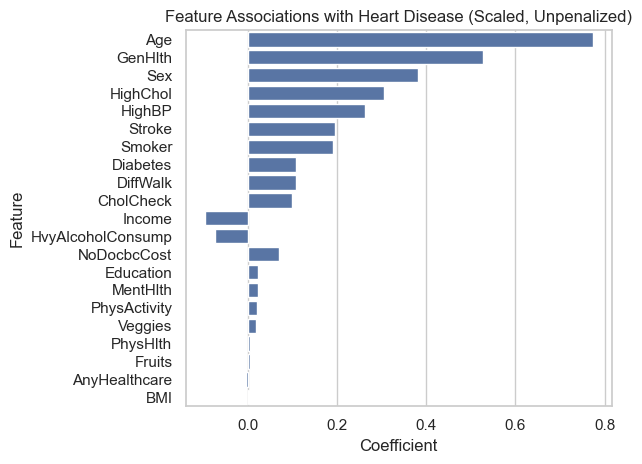

In [18]:
coef_df_pipeline = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': pipeline.named_steps['model'].coef_[0]
})
coef_df_pipeline = coef_df_pipeline.reindex(
    coef_df_pipeline['Coefficient'].abs().sort_values(ascending=False).index
)
print(coef_df_pipeline)

sns.barplot(data=coef_df_pipeline, x='Coefficient', y='Feature')
plt.title('Feature Associations with Heart Disease (Scaled, Unpenalized)')
plt.tight_layout()
plt.show()

## Final Model: Top 14 Stepwise-Selected Predictors

For the final model, I retained the **top 14 features** from the forward stepwise selection path, scaled them with `StandardScaler`, and refit a logistic regression. This model achieves a **test ROC AUC of ~0.845** while using roughly two-thirds of the original predictors, offering a good balance between predictive performance and interpretability.

In [19]:
top_features = selected_features[:14]

scaler = StandardScaler()
X_train_top = scaler.fit_transform(X_train[top_features])

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_top, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

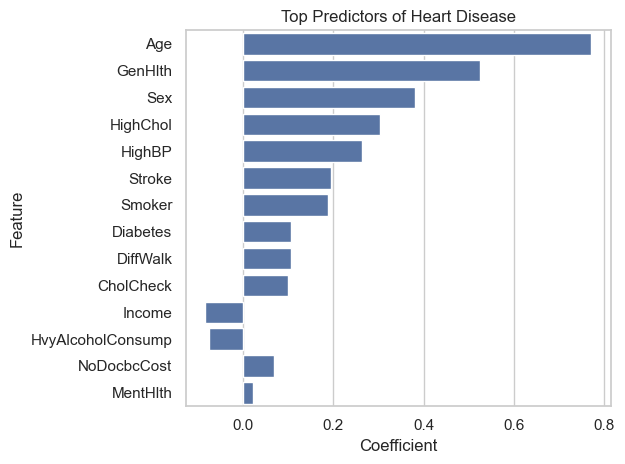

In [20]:
coef_df = pd.DataFrame({
    "Feature": top_features,
    "Coefficient": final_model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

sns.barplot(data=coef_df, x="Coefficient", y="Feature")
plt.title("Top Predictors of Heart Disease")
plt.tight_layout()
plt.show()

## Discussion

The final model, using 14 predictors selected via forward stepwise selection, achieves a test ROC AUC of approximately **0.845**, indicating strong discriminative ability between respondents with and without a history of heart disease or heart attack. Several findings stand out:

- **`GenHlth` (self-reported general health)** is selected first in the stepwise process, reflecting its role as a broad proxy that correlates with many underlying risk factors (age, BMI, activity level, chronic conditions). Despite entering first, its final standardized coefficient is smaller than that of more specific variables like `Stroke`, since stepwise selection prioritizes marginal predictive contribution at each step rather than final coefficient magnitude.
- **`HvyAlcoholConsump`** shows a negative association with heart disease in raw correlations, which initially seems counterintuitive. This is best explained by survivorship bias and the younger average age of heavy drinkers in the sample, rather than any protective effect of alcohol.
- Features related to chronic conditions (`Stroke`, `Diabetes`, `HighBP`, `HighChol`) and age consistently emerge as some of the strongest individual predictors, consistent with established clinical risk factors for cardiovascular disease.

## Conclusion and Limitations

This project demonstrates that a relatively simple, interpretable logistic regression model, built on a thoughtfully selected subset of 14 self-reported health and behavioral indicators, can achieve strong discriminative performance (ROC AUC ≈ 0.845) for identifying individuals with a history of heart disease or heart attack.

A few important caveats:

- **Inference vs. prediction:** Logistic regression coefficients are useful for understanding *associations*, but `HeartDiseaseorAttack` is self-reported and the data is cross-sectional, so these relationships should not be interpreted causally.
- **Class imbalance:** Heart disease is relatively rare in the overall population, so accuracy alone can be misleading; ROC AUC was used as the primary metric for this reason, since it is robust to class imbalance.
- **Model choice:** Ensemble methods (e.g. random forests, gradient boosting) could likely improve raw predictive performance further, but at the cost of the direct coefficient-based interpretability that logistic regression provides, which was a priority for this project's focus on identifying risk factors rather than maximizing prediction accuracy alone.

Overall, this analysis highlights both the value and the limits of simple, interpretable models for understanding population-level health risk factors, and underscores the importance of considering confounding and survivorship effects when interpreting observational health data.

---

*Data source: [CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015](https://www.cdc.gov/brfss/annual_data/annual_2015.html), accessed via Kaggle.*